## Cas D'étude : ATP  Tweaked : Préparé par Aymen Mejri

### Importation des librairies :

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, classification_report
from typing import List, Tuple, Union

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, GridSearchCV

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

sns.set()

### Chargement de la data : 

In [2]:
data = pd.read_csv('ATP_tweaked.csv', sep = ";")
data.drop_duplicates(inplace=True)

In [3]:
data.head()

,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_entry,p1_hand,p1_ht,p1_id,p1_ioc,p1_name,p1_rank,p1_rank_points,p1_seed,p1_won
0,3,66.0,47.0,26.0,15.0,9.0,9.0,8.0,6.0,112.0,...,NaN,R,188.0,104542,FRA,Jo Wilfried Tsonga,19.0,1645.0,NaN,0
1,3,45.0,33.0,21.0,13.0,6.0,9.0,6.0,5.0,87.0,...,NaN,R,NaN,105526,GER,Jan Lennard Struff,89.0,650.0,NaN,1
2,5,54.0,38.0,21.0,18.0,3.0,4.0,0.0,3.0,92.0,...,NaN,R,183.0,104527,SUI,Stanislas Wawrinka,5.0,5710.0,5.0,1
3,3,46.0,35.0,17.0,14.0,2.0,2.0,0.0,3.0,72.0,...,NaN,R,180.0,104655,URU,Pablo Cuevas,23.0,1447.0,6.0,0
4,3,42.0,33.0,13.0,11.0,10.0,1.0,0.0,1.0,68.0,...,Q,R,185.0,104433,CAN,Frank Dancevic,156.0,326.0,NaN,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12310 entries, 0 to 12309
Data columns (total 49 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   best_of         12310 non-null  int64  
 1   p2_1stIn        11902 non-null  float64
 2   p2_1stWon       11902 non-null  float64
 3   p2_2ndWon       11902 non-null  float64
 4   p2_SvGms        11902 non-null  float64
 5   p2_ace          11902 non-null  float64
 6   p2_bpFaced      11902 non-null  float64
 7   p2_bpSaved      11902 non-null  float64
 8   p2_df           11902 non-null  float64
 9   p2_svpt         11902 non-null  float64
 10  p2_age          12305 non-null  float64
 11  p2_entry        2006 non-null   object 
 12  p2_hand         12287 non-null  object 
 13  p2_ht           9167 non-null   float64
 14  p2_id           12310 non-null  int64  
 15  p2_ioc          12310 non-null  object 
 16  p2_name         12310 non-null  object 
 17  p2_rank         12170 non-null 

**Observations et constations:** 

Nous pouvons observer qu'il y a beaucoup de valeurs manquantes dans le jeu de données dont il faut remplacer les
valeurs. Le choix de la valeur doit être fait suite à une observation minutieuse de chaque variable en terme de distribution statistique ou en terme de significativité réelle.

Selon le jeu de données, nous pouvons évidemment conclure que la variable objective (Target object) à prédire est p1_won; si le premier joueur gagnerait la partie.

Ainsi, nous sommes face à un **problème supervisé de classification** où il est question de determiner selon la data dont on dispose si le premier joueur va gagner.

Les métriques qu'il faudrait donc utiliser pour juger la performance du modèle sont :

- Accuracy
- Precision
- Recall
- F1-score : une mesure qui permet de donner une valeur équilibrée entre la précision et le recall

### EDA : Exploratory data analysis : 

La première chose à faire est de distinguer les différents types de variables présentes sur le dataset c'est à dire voir s'ils correspondent à des variables catégoriques, numériques ou ordinales.

- **Les variables catégoriques** prennent en effet des valeurs dans un ensemble finit de valeur, la question qui reste à savoir est le cardinal de cette ensemble. **Nous supposerons que la valeur limite à partir de laquelle nous considérerons la variable comme non catégorique est 10**

- **Les variables numériques** sont ceux qui prennent des valeurs entières ou réelles et ils sont faciles à identifier. Il faut faire attention à un point certaines variables prennent des valeurs numériques mais ne correspondent pas à des variables numériques comme par exemple les Ids ou les valeurs ordinales qu'il faudrait donc distinguer 

- **Les valeurs ordinales** sont des variables dont les valeurs sont définies par une relation d’ordre entre les catégories possibles et sont souvent des valeurs entières.

In [5]:
y = data["p1_won"]
X = data.drop(columns=['p1_won'])

Il faut comencer tout d'abord par virer les colonnes :
- ids des joeurs et des tournois 
- des noms des joueurs et des tournois

In [6]:
X.drop(columns=["tourney_name", "tourney_id", "p2_name", "p1_name", "p2_id", "p1_id"], inplace=True)

#### Identifier les variables catégoriques : 

In [7]:
def categorical_var_preselection(data: pd.DataFrame, threshold: int = 10) -> List[str]:
    """
    Preselect categorical columns.
    """
    return [c for c in data.columns if data[c].nunique() <= threshold]

In [8]:
categorical_variables = categorical_var_preselection(X)
print("Categorical variables : \n - {}".format("\n - ".join(categorical_variables)))

Categorical variables : 
 - best_of
 - p2_entry
 - p2_hand
 - round
 - surface
 - tourney_level
 - p1_entry
 - p1_hand


**Remarque :** La colonne ioc est aussi une variable categorique mais n'a pas été selectionné vu que le nombre de valeur possible est 85 et devra donc prendre prise en considération

In [9]:
categorical_variables.append("p1_ioc")
categorical_variables.append("p2_ioc")

**Identifier les variables numériques et ordinales:**

Comme je l'ai indiqué ci-dessus les variables numériques correspondent sont les variables qui prennent des valeurs entières ou numériques, la première chose à faire est d'éliminer les colonnes identifiées comme étant catégoriques et de séléctionner de celles qui restent, celles qu'on qualifierait comme numérique.

In [10]:
df = X.drop(categorical_variables, axis=1)

In [11]:
def numerical_var_preselection(data: pd.DataFrame) -> List[str]:
    """
    Preselect numerical columns.
    """
    return data.describe().columns

In [12]:
numerical_variables = numerical_var_preselection(df)
print("Numerical variables : \n - {}".format("\n - ".join(numerical_variables)))

Numerical variables : 
 - p2_1stIn
 - p2_1stWon
 - p2_2ndWon
 - p2_SvGms
 - p2_ace
 - p2_bpFaced
 - p2_bpSaved
 - p2_df
 - p2_svpt
 - p2_age
 - p2_ht
 - p2_rank
 - p2_rank_points
 - p2_seed
 - match_num
 - minutes
 - tourney_date
 - p1_1stIn
 - p1_1stWon
 - p1_2ndWon
 - p1_SvGms
 - p1_ace
 - p1_bpFaced
 - p1_bpSaved
 - p1_df
 - p1_svpt
 - p1_age
 - p1_ht
 - p1_rank
 - p1_rank_points
 - p1_seed


**Observations :** Nous pouvons constater sur les variables présélectionnées comme étant numérique que certaines sont plutôt ordinales dans la mesure où il représente une certaine relation d'ordre. Les colonnes en question sont les suivantes:
    
- La taille :
    - p2_ht
    - p1_ht
- L'age :
    - p2_age
    - p1_age
- Le rang des joueurs:
    - p2_rank
    - p1_rank
- Le nombre de point gagnés sur le rang de l'ATP:
    - p2_rank_points
    - p1_rank_points
    
Un autre point intéressant que j'ai observé est que la variable **tourney_date** est indiquée sous forme numérique alors que ce n'est pas le format adéquat pour représenter une date et qui nécessite donc un prétraitement.

#### Dealing with Nan values:

In [13]:
def get_columns_with_nan_values(data: pd.DataFrame) -> List[str]:
    """
    Find columns that contain nan values.
    """
    nb_lines = data.shape[0]
    return [c for c in data.columns if data[c].count() < nb_lines]

In [14]:
cols_with_nans = get_columns_with_nan_values(X)

In [15]:
def info_nan_col(data: pd.DataFrame, cols: List[str]) -> List[str]:
    """
    Get meta data about numerical columns.
    """
    return [" - ".join([c, "type : " + str(X[c].dtype), f"ratio nan : {round((1 - data[c].count()/data.shape[0]) * 100, 2)} %" ]) for c in cols_with_nans]
print("Columns with nan values : \n - {}".format("\n - ".join(info_nan_col(data, cols_with_nans))))

Columns with nan values : 
 - p2_1stIn - type : float64 - ratio nan : 3.31 %
 - p2_1stWon - type : float64 - ratio nan : 3.31 %
 - p2_2ndWon - type : float64 - ratio nan : 3.31 %
 - p2_SvGms - type : float64 - ratio nan : 3.31 %
 - p2_ace - type : float64 - ratio nan : 3.31 %
 - p2_bpFaced - type : float64 - ratio nan : 3.31 %
 - p2_bpSaved - type : float64 - ratio nan : 3.31 %
 - p2_df - type : float64 - ratio nan : 3.31 %
 - p2_svpt - type : float64 - ratio nan : 3.31 %
 - p2_age - type : float64 - ratio nan : 0.04 %
 - p2_entry - type : object - ratio nan : 83.7 %
 - p2_hand - type : object - ratio nan : 0.19 %
 - p2_ht - type : float64 - ratio nan : 25.53 %
 - p2_rank - type : float64 - ratio nan : 1.14 %
 - p2_rank_points - type : float64 - ratio nan : 1.14 %
 - p2_seed - type : float64 - ratio nan : 66.5 %
 - minutes - type : float64 - ratio nan : 14.05 %
 - p1_1stIn - type : float64 - ratio nan : 3.31 %
 - p1_1stWon - type : float64 - ratio nan : 3.31 %
 - p1_2ndWon - type : flo

In [16]:
def check_nan_values(data: pd.DataFrame, col: str, player: int):
    """
    Try to fill nan values with some values related to the player if it's indicated in other rows of the dataset 
    """
    def intersection(lst1: List[str], lst2: list):
        return list(set(lst1) & set(lst2))
    null = [i for i in data[data[col].isnull()][f"p{player}_id"].to_list()]
    not_null = [i for i in data[data[col].notnull()][f"p{player}_id"].to_list()]
    return intersection(null, not_null)

In [17]:
print(check_nan_values(data, "p2_ht", 2))
print(check_nan_values(data, "p1_ht", 1))

[]
[]


In [18]:
import numpy as np
def check_seed_na(data):
    """
    The idea is to check if there is a not appropriately annotated data where for the same tourney and the same player,
    seed are indicated for some rows but not for others.
    """
    data["year"] = data["tourney_date"]//10000
    # data with non null seed
    non_null = data[data["p1_seed"].notnull()][["tourney_id", "year", "p1_seed", "p1_id"]]
    # non null seed for player per tourney and year 
    p1_seed_dict = { (non_null.iloc[i]["tourney_id"], non_null.iloc[i]["year"], non_null.iloc[i]["p1_id"]) : non_null.iloc[i]["p1_seed"] for i in range(non_null.shape[0])}
    
    # data with null seed
    null = data[data["p1_seed"].isnull()][["tourney_id", "year", "p1_seed", "p1_id"]]
    return pd.concat([null[(null.tourney_id == k[0]) & (null.year == k[1]) & (null.p1_id==k[2])] for k in p1_seed_dict])


In [19]:
check_seed_na(data)

,tourney_id,year,p1_seed,p1_id


**Constatations :**

- Pour les colonnes 1stIn, 1stWon, 2ndWon, SvGms, ace, bpFaced, bpSaved, df, svpt, rank, rank_points et age, la proportion de valeurs manquantes n'est pas aussi importantes. Etant donnée que ce sont toutes des variables numériques, il parrait judicieux de remplacer les valeurs nans par la valeur median ( je choisis la médian et non pas la moyenne pour éviter tout impact des outliers que j'étudierai plus tard) 

- Pour la colonne ht la proportion de valeurs null est importante(25%). une première méthode que j'ai testée est d'explorer s'il y a des lignes où pour un même joueur on a auparavant indiqué la taille sur une autre ligne. le resultat de l'intersection a donné une liste vide. donc la façon la plus judicieuse pour remplacer les valeurs manquantes est aussi de le remplacer par la valeur médiane.

- Pour l'entry qui est une variable catégorique le plus simple et de rajouter un label "unknown" pour les valeurs non indiqué.  

- Pour le nombre de minutes, il semble judicieux de le remplacer par la valeur médiane
- pour la variable seed, la variable est plutot catégorique et nous pouvons aussi considérer les valeurs manquantes comme une classe à part entière "unknown"

- Pour la colonne hand, la présence de valeur nan est minime. Nous pouvons nous permettre de supprimer les lignes correspondantes sont vraiment perdre de la data et aussi eviter d'introduire un biais.

In [20]:
class FillNan:
    def __init__(self, X, y, col_median, col_categorical):
        self.data = X.copy()
        self.data["label"] = y.tolist()
        self.col_median = col_median
        self.col_categorical = col_categorical
    
    def _fill_with_median(self):
        """
        Fill nan values with median.
        """
        for c in self.col_median:
            self.data[c] = self.data[c].fillna((self.data[c].median()))
                        
    def _fill_categorical(self):
        """
        Consider nan values as a category
        """
        for c in self.col_categorical:
            self.data[c] = self.data[c].astype('str').replace("nan", "unk") 
    
    def fillna(self) -> pd.DataFrame:
        """
        Fill nan values for all variables.
        """
        self._fill_with_median()
        self._fill_categorical()
        ## drop the value of the hand column:
        self.data.dropna(inplace=True)
        self.data.reset_index(inplace=True, drop=True)
        
        y = self.data["label"]
        X = self.data.drop(columns=['label'])
        return X, y

In [21]:
cols_median = [[f"p{p}_1stIn", f"p{p}_1stWon", 
              f"p{p}_2ndWon", f"p{p}_SvGms", 
              f"p{p}_ace", f"p{p}_bpFaced", 
              f"p{p}_bpSaved", f"p{p}_df", 
              f"p{p}_svpt", f"p{p}_rank", 
              f"p{p}_rank_points", f"p{p}_age", 
              f"p{p}_ht"] for p in range(1,3)]
cols_median = cols_median[0] + cols_median[1] + ["minutes"]

col_categorical = [f"p1_seed", f"p1_entry", f"p2_seed", f"p2_entry"]
fillna = FillNan(X, y, cols_median, col_categorical)

In [22]:
X, y = fillna.fillna()

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12264 entries, 0 to 12263
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   best_of         12264 non-null  int64  
 1   p2_1stIn        12264 non-null  float64
 2   p2_1stWon       12264 non-null  float64
 3   p2_2ndWon       12264 non-null  float64
 4   p2_SvGms        12264 non-null  float64
 5   p2_ace          12264 non-null  float64
 6   p2_bpFaced      12264 non-null  float64
 7   p2_bpSaved      12264 non-null  float64
 8   p2_df           12264 non-null  float64
 9   p2_svpt         12264 non-null  float64
 10  p2_age          12264 non-null  float64
 11  p2_entry        12264 non-null  object 
 12  p2_hand         12264 non-null  object 
 13  p2_ht           12264 non-null  float64
 14  p2_ioc          12264 non-null  object 
 15  p2_rank         12264 non-null  float64
 16  p2_rank_points  12264 non-null  float64
 17  p2_seed         12264 non-null 

**Dealing with outliers :**

- Le degré de la distorsion et le coefficient d'étalement renseignent sur la symétrie de la distribution et la répartition des valeurs. Le fait d'avoir un degré de distorsion et un facteur d'étalement élévés peut révéler la présence d'outliers qui peuvent affecter le résultat de la prédiction. Nous souhaitons avoir un degré de distorsion proche de 0 qui traduit une certaine symétrie de la courbe par rapport à la moyenne et une valeur du coefficient d'étalement inférieur à un seuil.Lorsqu'on observe une valeur élevée du degré de distorsion, il est possible d'appliquer la fonction logarithme qui permet de rendre la courbe plus symétrique (diminuer le degré de distorsion).

In [24]:
def skewness_analysis(data: pd.DataFrame, col_name: list, treshold_skewness: float = 0.5) -> bool:
    """
    inputs :
        - data : the dataframe
        - col_name : the dataframe columns
        - threshold_skewness : Based on the Pearson's 1st and 2nd coffecient of skewness:
            1st : (mean-mode)/std 
            2nd : 3(mean-median)/std
          we can say that :
              - if skewness is between -0.5 and 0.5 than the data is symmetrical
              - if |skewness| is between 0.5 and 1 than the data is sligntly skewed
              - if |skewness| is greater than 1 the data is extremely skewed
          The threshold should be 0.5
    Output:
        - process : if we have to apply the transformation
    """
    process = False
    fig, ax = plt.subplots(figsize=(20, 5))
    sns.distplot(data.dropna()[col_name], ax=ax, label=col_name)
    print("column exploratory {} :\n".format(col_name))
    print("Skewness : {:.3f}".format(
        data.dropna()[col_name].skew()))
    print("Kurtosis : {:.3f}\n".format(
        data.dropna()[col_name].kurt()))
    if (np.abs(round(data.dropna()[col_name].skew(), 3)) > treshold_skewness):
        process = True
        print("## After processing the data : ## \n")
        print("Skewness : {:.3f}".format(
            data.dropna()[col_name].apply(lambda x: np.log1p(x)).skew()))
        print("Kurtosis : {:.3f}".format(
            data.dropna()[col_name].apply(lambda x: np.log1p(x)).kurt()))
        sns.distplot(
            np.log1p(data.dropna()[col_name]), ax=ax, label=f"{col_name} with log1P")

    else:
        print("## No need to process the data ##")

    plt.title(f'column distribution {col_name}')
    plt.legend()
    plt.show()
    return process

In [25]:
def apply_sk_kurt_transform(data: pd.DataFrame, numerical_cols: List[str], treshold_skewness: float = 0.5) -> List[str]:
    columns_to_transform = []
    for col_name in numerical_cols:
        skewness = np.abs(round(data[col_name].skew(), 3))
        if (skewness > treshold_skewness):
            columns_to_transform.append(col_name)
    return columns_to_transform

In [26]:
sk_kt_study_list = [n for n in numerical_variables if n not in ["p1_ht", "p1_age", "p1_rank", "p1_rank_points", "p1_seed", "p2_ht", "p2_age", "p2_rank", "p2_rank_points", "p2_seed"]]

- p2_1stIn ---------------------------------------------------------------------------------------------------- 

column exploratory p2_1stIn :

Skewness : 1.091
Kurtosis : 2.229

## After processing the data : ## 

Skewness : -0.723
Kurtosis : 5.037


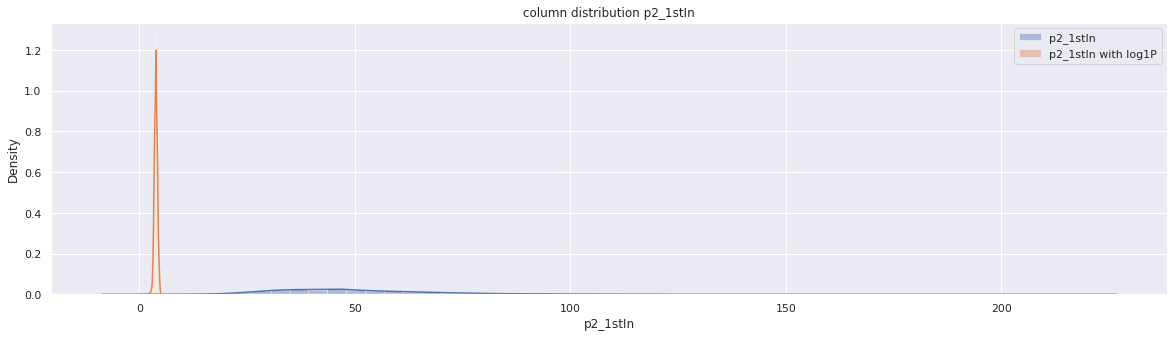

- p2_1stWon ---------------------------------------------------------------------------------------------------- 

column exploratory p2_1stWon :

Skewness : 1.093
Kurtosis : 2.709

## After processing the data : ## 

Skewness : -0.816
Kurtosis : 4.309


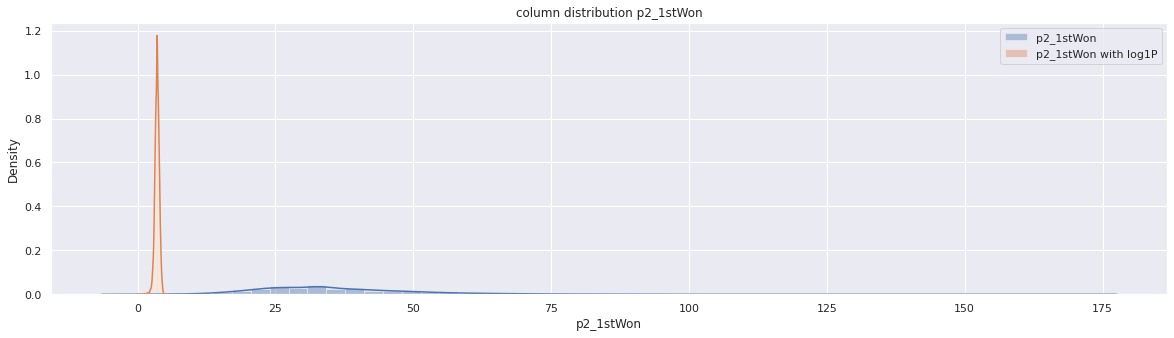

- p2_2ndWon ---------------------------------------------------------------------------------------------------- 

column exploratory p2_2ndWon :

Skewness : 0.854
Kurtosis : 1.131

## After processing the data : ## 

Skewness : -0.679
Kurtosis : 1.753


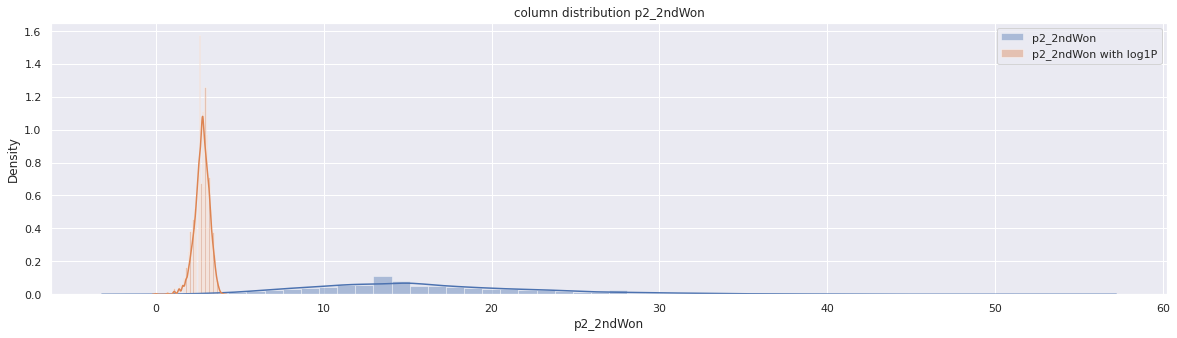

- p2_SvGms ---------------------------------------------------------------------------------------------------- 

column exploratory p2_SvGms :

Skewness : 1.126
Kurtosis : 2.397

## After processing the data : ## 

Skewness : -0.338
Kurtosis : 3.208


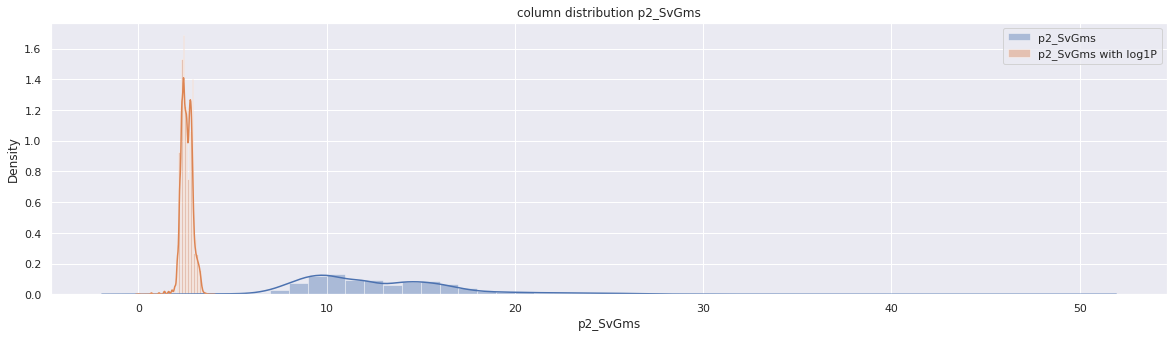

- p2_ace ---------------------------------------------------------------------------------------------------- 

column exploratory p2_ace :

Skewness : 2.146
Kurtosis : 9.053

## After processing the data : ## 

Skewness : -0.336
Kurtosis : 0.001


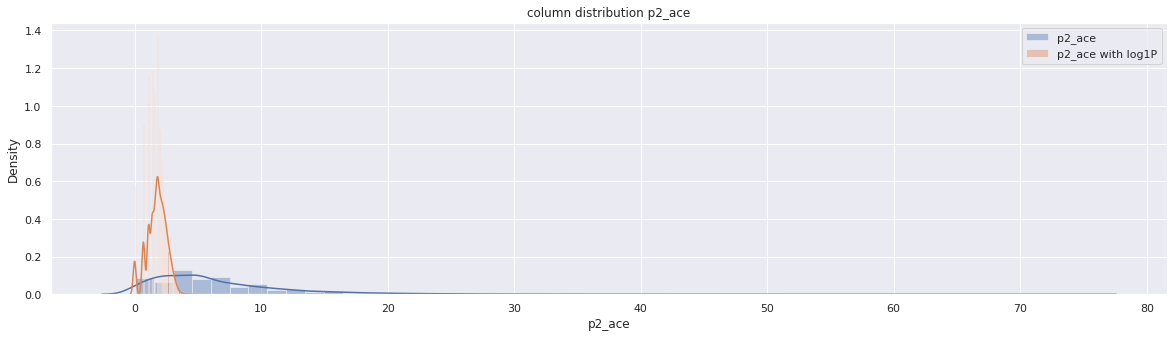

- p2_bpFaced ---------------------------------------------------------------------------------------------------- 

column exploratory p2_bpFaced :

Skewness : 0.807
Kurtosis : 0.781

## After processing the data : ## 

Skewness : -0.888
Kurtosis : 0.600


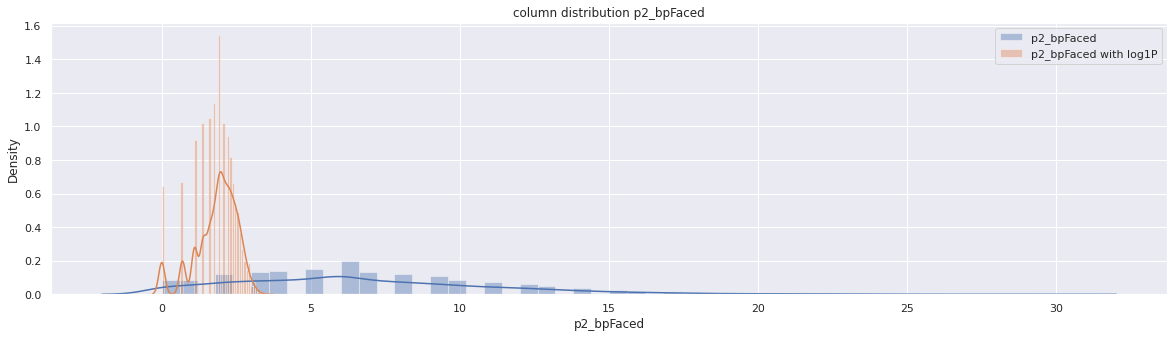

- p2_bpSaved ---------------------------------------------------------------------------------------------------- 

column exploratory p2_bpSaved :

Skewness : 1.076
Kurtosis : 1.573

## After processing the data : ## 

Skewness : -0.508
Kurtosis : -0.357


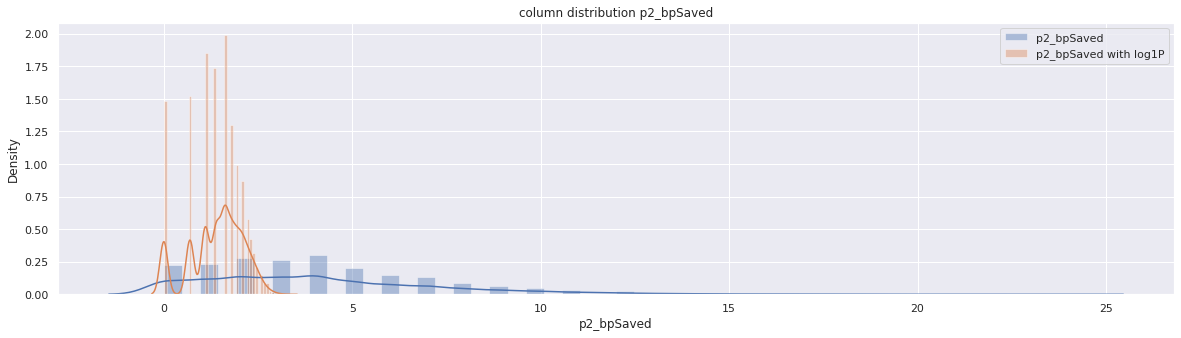

- p2_df ---------------------------------------------------------------------------------------------------- 

column exploratory p2_df :

Skewness : 1.271
Kurtosis : 2.637

## After processing the data : ## 

Skewness : -0.360
Kurtosis : -0.299


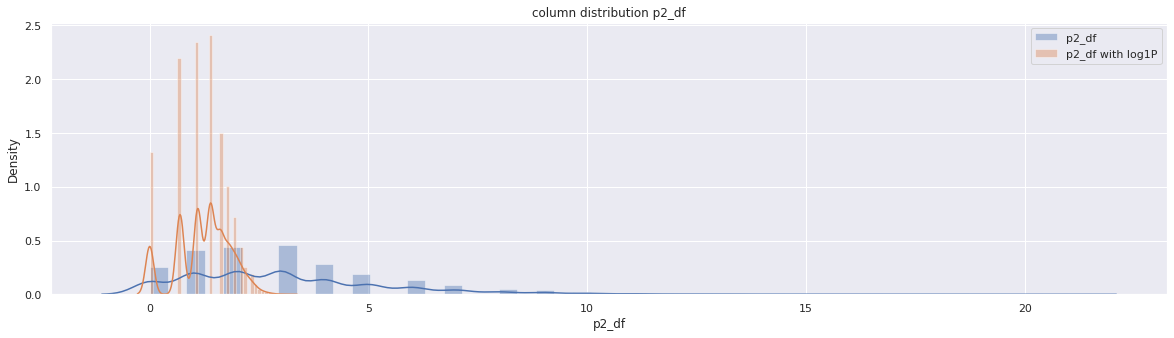

- p2_svpt ---------------------------------------------------------------------------------------------------- 

column exploratory p2_svpt :

Skewness : 1.016
Kurtosis : 1.652

## After processing the data : ## 

Skewness : -0.859
Kurtosis : 7.499


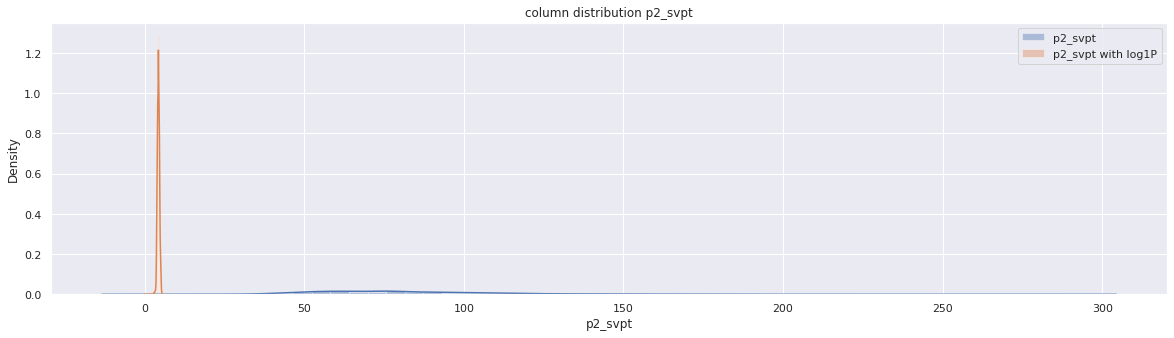

- match_num ---------------------------------------------------------------------------------------------------- 

column exploratory match_num :

Skewness : -0.538
Kurtosis : -1.298

## After processing the data : ## 

Skewness : -1.297
Kurtosis : 0.248


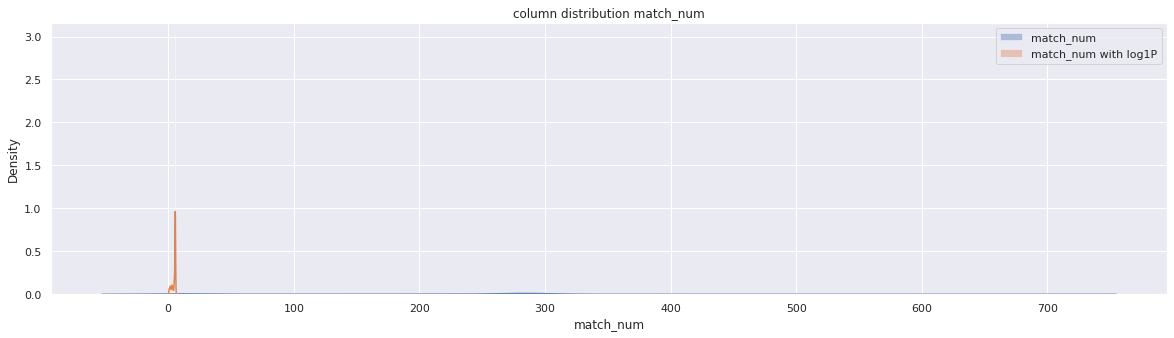

- minutes ---------------------------------------------------------------------------------------------------- 

column exploratory minutes :

Skewness : 3.213
Kurtosis : 54.114

## After processing the data : ## 

Skewness : -0.463
Kurtosis : 4.388


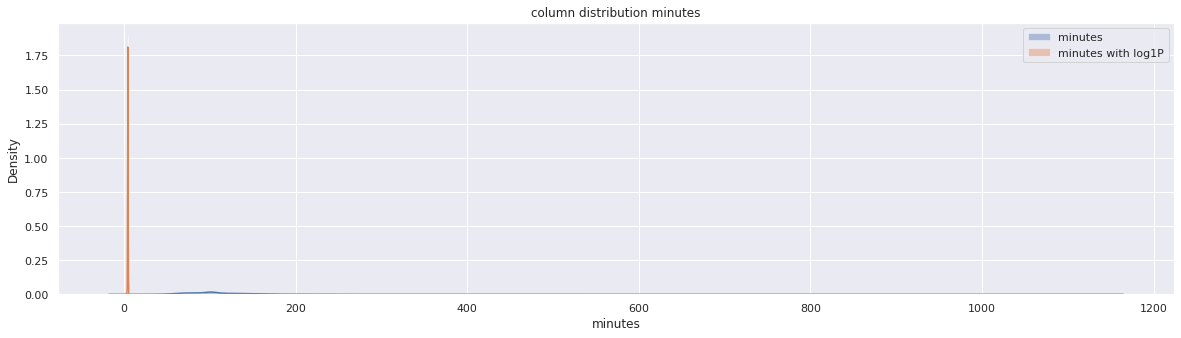

- tourney_date ---------------------------------------------------------------------------------------------------- 

column exploratory tourney_date :

Skewness : 0.107
Kurtosis : -1.159

## No need to process the data ##


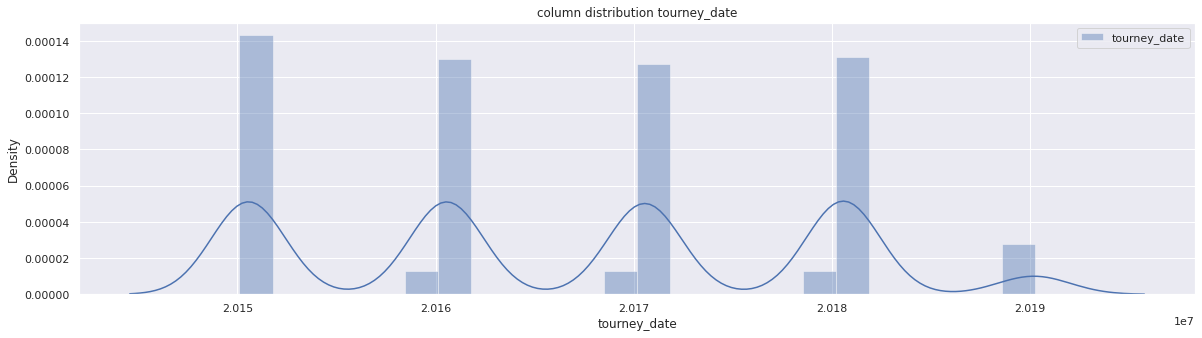

- p1_1stIn ---------------------------------------------------------------------------------------------------- 

column exploratory p1_1stIn :

Skewness : 1.080
Kurtosis : 2.047

## After processing the data : ## 

Skewness : -0.538
Kurtosis : 3.160


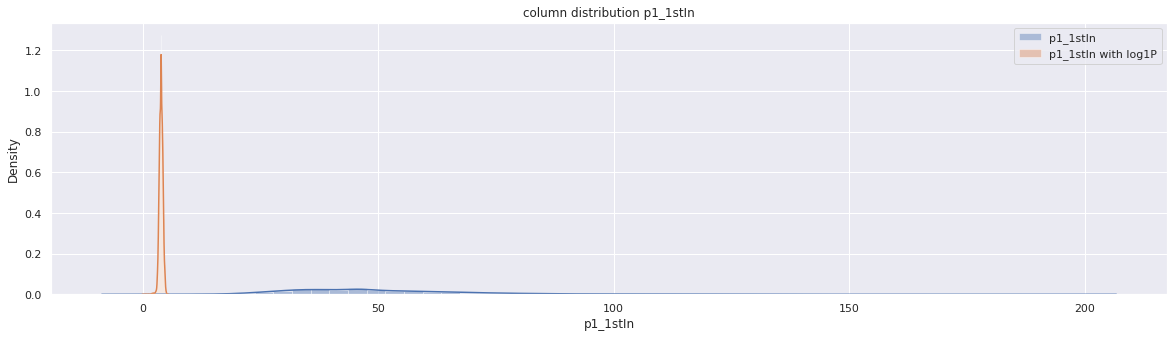

- p1_1stWon ---------------------------------------------------------------------------------------------------- 

column exploratory p1_1stWon :

Skewness : 1.087
Kurtosis : 2.589

## After processing the data : ## 

Skewness : -0.674
Kurtosis : 3.011


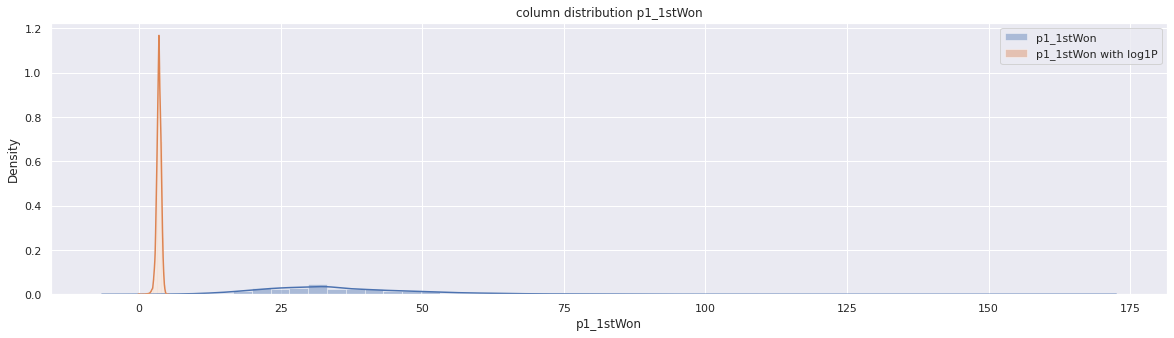

- p1_2ndWon ---------------------------------------------------------------------------------------------------- 

column exploratory p1_2ndWon :

Skewness : 0.844
Kurtosis : 1.194

## After processing the data : ## 

Skewness : -0.742
Kurtosis : 2.117


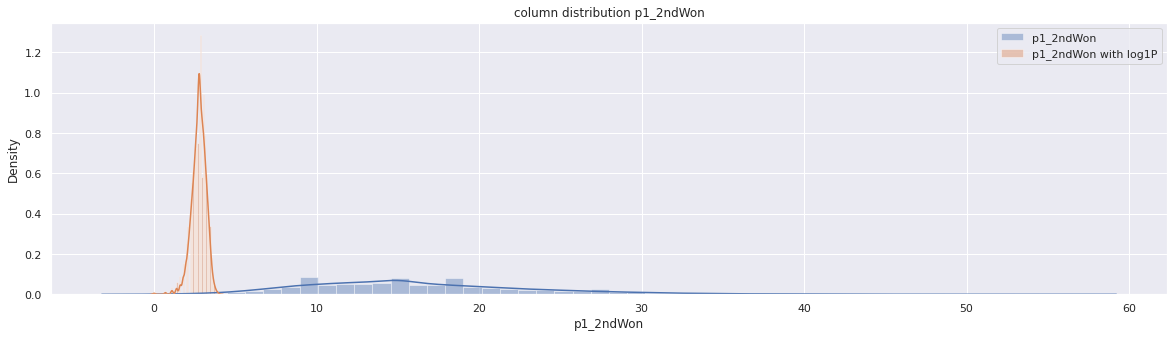

- p1_SvGms ---------------------------------------------------------------------------------------------------- 

column exploratory p1_SvGms :

Skewness : 1.125
Kurtosis : 2.309

## After processing the data : ## 

Skewness : -0.240
Kurtosis : 2.478


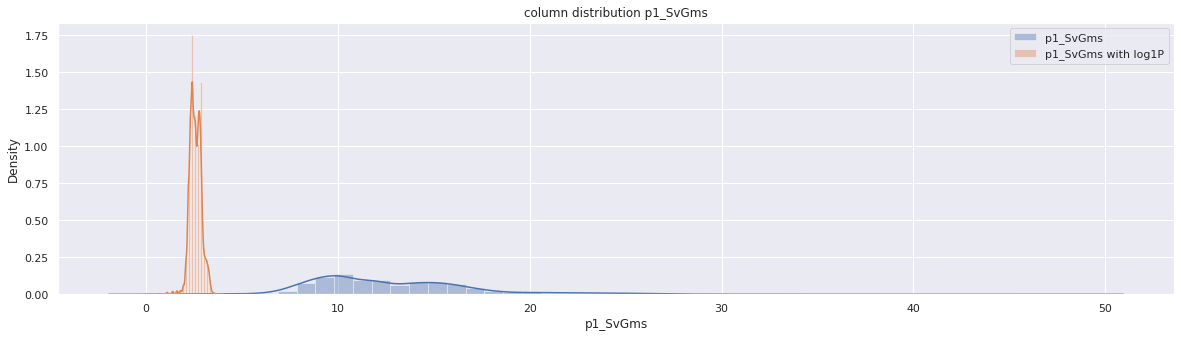

- p1_ace ---------------------------------------------------------------------------------------------------- 

column exploratory p1_ace :

Skewness : 2.112
Kurtosis : 8.094

## After processing the data : ## 

Skewness : -0.341
Kurtosis : -0.023


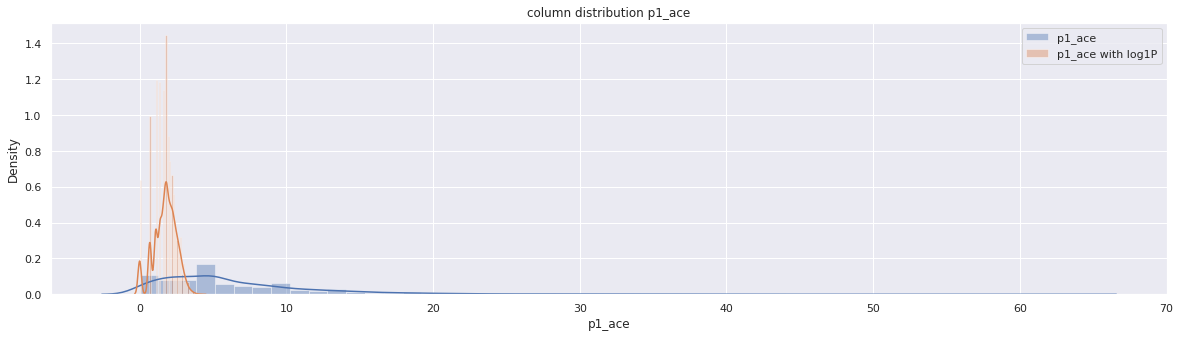

- p1_bpFaced ---------------------------------------------------------------------------------------------------- 

column exploratory p1_bpFaced :

Skewness : 0.838
Kurtosis : 1.027

## After processing the data : ## 

Skewness : -0.933
Kurtosis : 0.694


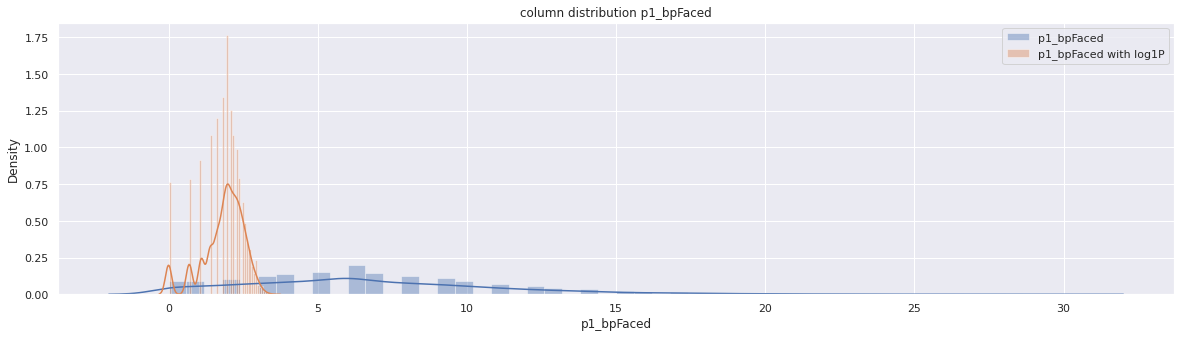

- p1_bpSaved ---------------------------------------------------------------------------------------------------- 

column exploratory p1_bpSaved :

Skewness : 1.116
Kurtosis : 1.768

## After processing the data : ## 

Skewness : -0.507
Kurtosis : -0.339


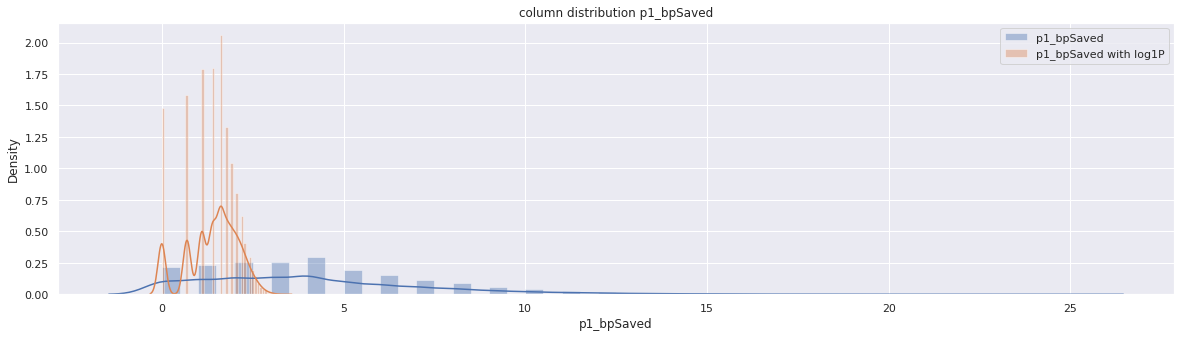

- p1_df ---------------------------------------------------------------------------------------------------- 

column exploratory p1_df :

Skewness : 1.342
Kurtosis : 3.006

## After processing the data : ## 

Skewness : -0.354
Kurtosis : -0.263


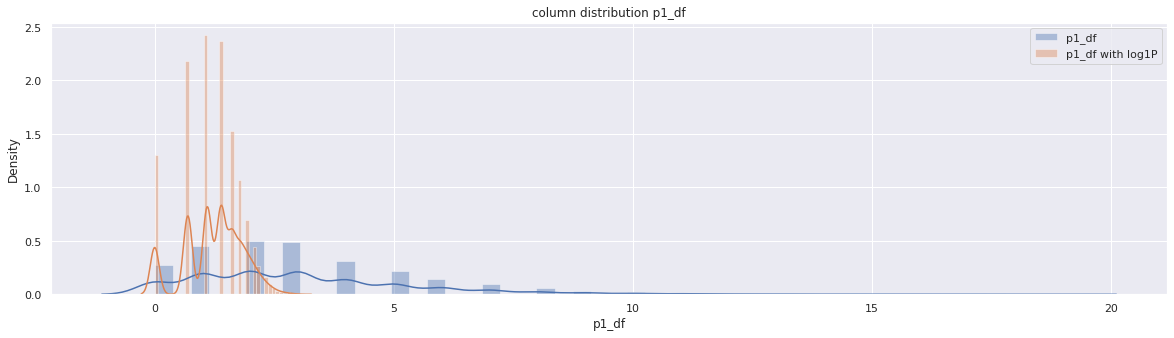

- p1_svpt ---------------------------------------------------------------------------------------------------- 

column exploratory p1_svpt :

Skewness : 0.997
Kurtosis : 1.590

## After processing the data : ## 

Skewness : -0.581
Kurtosis : 3.772


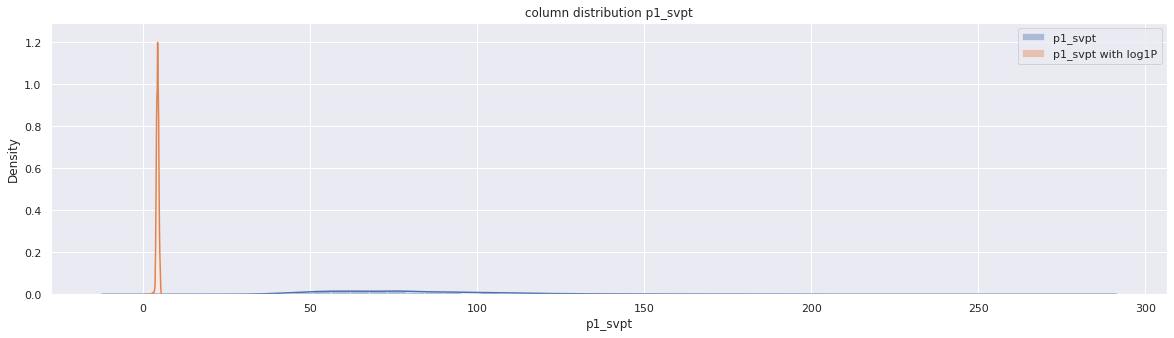

In [27]:
for col in sk_kt_study_list:
    print( f"- {col} {'-'*100} \n")
    process = skewness_analysis(X, col)

In [28]:
columns_to_process = apply_sk_kurt_transform(X, sk_kt_study_list)
print("les colonnes sur lesquelles il faudrait appliquer des transformations sont :")
for col in columns_to_process:
    print(" - ", col)

les colonnes sur lesquelles il faudrait appliquer des transformations sont :
 -  p2_1stIn
 -  p2_1stWon
 -  p2_2ndWon
 -  p2_SvGms
 -  p2_ace
 -  p2_bpFaced
 -  p2_bpSaved
 -  p2_df
 -  p2_svpt
 -  match_num
 -  minutes
 -  p1_1stIn
 -  p1_1stWon
 -  p1_2ndWon
 -  p1_SvGms
 -  p1_ace
 -  p1_bpFaced
 -  p1_bpSaved
 -  p1_df
 -  p1_svpt


## Feature engineering : 

In [29]:
class FeatureEngineering:
    def __init__(self, data: pd.DataFrame, categorical_cols: List[str], sk_kt_cols: List[str]) -> None:
        self.data = data.copy()
        self.categorical_cols = categorical_cols
        self.sk_kt_cols = sk_kt_cols
        
    def _split_date(self) -> None:
        """
        Extract the year, the month and the day from the column tourney date.
        """
        self.data["day"] = self.data["tourney_date"]%100
        self.data["month"] = (self.data["tourney_date"]//100)%100
        self.data["year"] = self.data["tourney_date"]//10000
        self.data.drop(columns=["tourney_date"], inplace=True)
    
    def _importance_tourney(self) -> None:
        """
        Set A new column which represent the importance of the tourney.
        """
        importance_dict = {"G":6, "M": 5, "A": 4, "C": 4, "S": 3, "F" : 2, "D": 1}
        importance = [importance_dict[k] for k in self.data["tourney_level"].tolist()]
        self.data["tourney_importance"] = importance
        
    def _sets_per_match(self) -> None:
        """
        Get the number of set per match.
        """
        self.data["nbr_sets"] = [len(match.split()) for match in self.data["score"]]
    
    def _game_per_match(self) -> None:
        """
        Get the number of game played during a match.
        """
        games_during_all_matchs = [[g.split('-') for g in match.split()] for match in self.data["score"]]
        
        games_list = []
        for s in games_during_all_matchs:
            games = 0 
            for g in s :
                try:
                    games += int(g[0]) + int(g[1]) 
                except:
                    continue
            games_list.append(games)
            
        self.data['games_per_match'] = games_list
        self.data.drop(columns=["score"], inplace=True)
        
    def _process_categorical_data(self) -> None:
        """
        Apply get dummies for categorical data.
        """
        self.data = pd.get_dummies(self.data, columns=self.categorical_cols)
        
    def _log_transform(self) -> None:
        """
        Apply log function to normalize numerical columns that need to be transformed
        """
        for col in self.sk_kt_cols:
            try:
                self.data[f'log_{col}'] = np.log1p(self.data[col])
            except:
                self.sk_kt_cols.remove(col)
        self.data.drop(columns=self.sk_kt_cols, inplace=True)
    
    def _transform_seed_as_categorical(self):
        """
        Consider seed as a categorical variable.
        """
        for p in [1, 2]:    
            self.data[f"p{p}_seed"] = self.data[f"p{p}_seed"].astype(str)
            self.categorical_cols.append(f"p{p}_seed")
    
    def transform(self) -> pd.DataFrame:
        """
        Apply the feature engineering pipeline.
        """
        # Add date features : 
        self._split_date()
        # Add importance tourney feature:
        self._importance_tourney()
        # Add number of set per match:
        self._sets_per_match()
        # Add the number of game pet match:
        self._game_per_match()
        # Scale numerical data in order to deal with outliers problem:
        self._log_transform()
        # Transform seed column as categorical variable
        self._transform_seed_as_categorical()
        # create a dummies variables for categorical data
        self._process_categorical_data()
        return self.data
    

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)

X_test.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

In [31]:
fe = FeatureEngineering(X_train, categorical_variables, sk_kt_study_list)
X_train = fe.transform()

fe = FeatureEngineering(X_test, categorical_variables, sk_kt_study_list)
X_test = fe.transform()

In [32]:
print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)

X_train shape :  (11037, 315)
X_test shape :  (1227, 349)


## Etude de la redondance d'information:

Etudier la redondance d'information, revient à étudier la corrélation qui existe entre les différents variables. plus les variables sont corrélées plus leur présence représente une redondance et conduit donc à une détérioration du modèle. Il faudrait donc procéder à l'élimination de l'une d'elles.

Pour étudier la corrélation des différentes variables, je vais dresser leur matrice de corrélation:

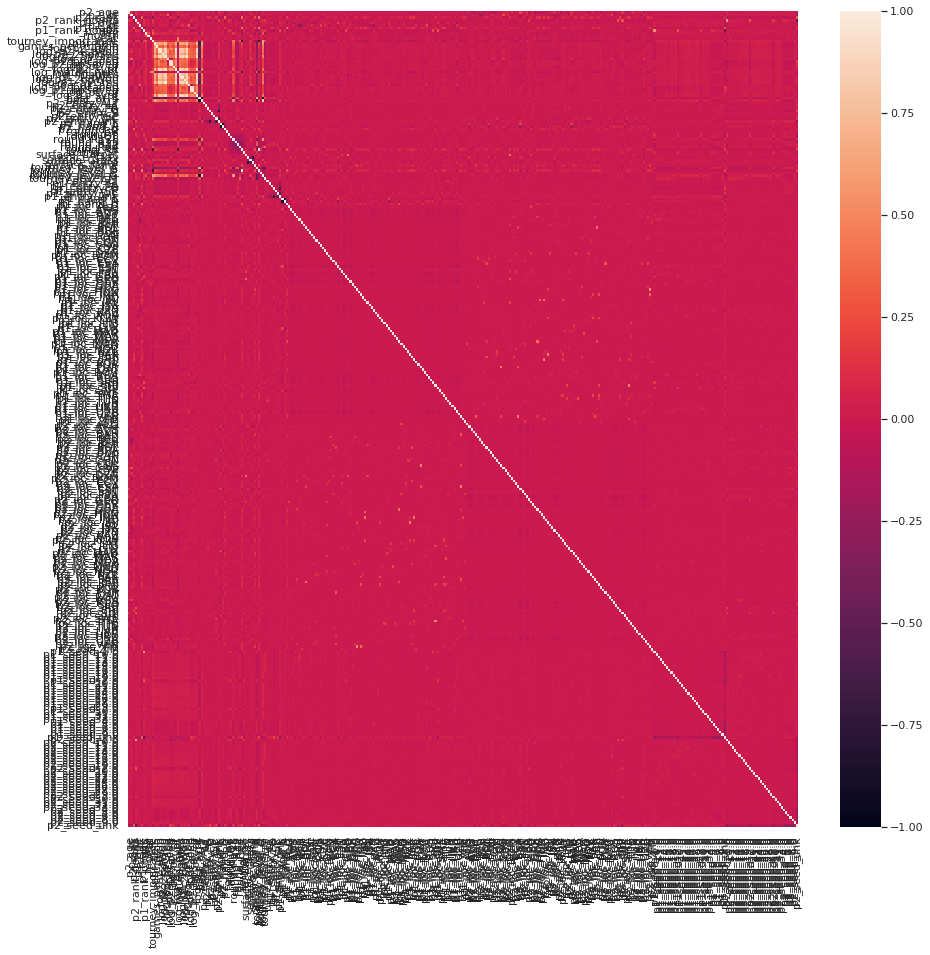

In [33]:
corr = X_train.corr()
plt.figure(figsize=(15, 15))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns);

In [34]:
# I will consider that to variables are correlated if absolute correlation value is up to 80% :
correlated = [(i,j) for i in corr.columns for j in corr.columns if i>j and abs(corr[i][j]) >= 0.8]

In [35]:
print("Correlated tuples :")
for c in correlated:
    print(f' - {c[0]}, {c[1]}')

Correlated tuples :
 - log_p2_1stIn, log_minutes
 - log_p2_1stIn, log_p1_1stWon
 - log_p2_1stIn, log_p1_SvGms
 - log_p2_1stIn, log_p1_svpt
 - log_p2_1stWon, log_p2_1stIn
 - log_p2_1stWon, log_p1_SvGms
 - log_p2_1stWon, log_p1_svpt
 - log_p2_SvGms, log_p2_1stIn
 - log_p2_SvGms, log_p2_1stWon
 - log_p2_SvGms, log_minutes
 - log_p2_SvGms, log_p1_1stWon
 - log_p2_SvGms, log_p1_SvGms
 - log_p2_SvGms, log_p1_svpt
 - log_p2_bpSaved, log_p2_bpFaced
 - log_p2_svpt, log_p2_1stIn
 - log_p2_svpt, log_p2_1stWon
 - log_p2_svpt, log_p2_SvGms
 - log_p2_svpt, log_minutes
 - log_p2_svpt, log_p1_1stWon
 - log_p2_svpt, log_p1_SvGms
 - log_p2_svpt, log_p1_svpt
 - log_p1_SvGms, log_minutes
 - log_p1_SvGms, log_p1_1stWon
 - log_p1_bpSaved, log_p1_bpFaced
 - log_p1_svpt, log_minutes
 - log_p1_svpt, log_p1_1stWon
 - log_p1_svpt, log_p1_SvGms
 - best_of_5, best_of_3
 - p2_hand_R, p2_hand_L
 - tourney_level_D, round_RR
 - tourney_level_G, best_of_3
 - tourney_level_G, best_of_5
 - p1_hand_R, p1_hand_L


En regardant la liste, et en se basant sur le nombre d'occurence des colonnes correlées, il parait judicieux d'éliminer les colonnes suivantes :

- log_p2_1stIn
- log_p2_1stWon
- log_minutes
- log_p2_SvGms
- log_p2_svpt
- p2_hand_L
- best_of_3
- best_of_5 
- p1_hand_L



In [36]:
columns_to_drop = ["log_p2_1stIn", "log_p2_1stWon", "log_minutes", "log_p2_SvGms", "log_p2_svpt", "p2_hand_L", "best_of_3", "best_of_5" ,"p1_hand_L"]
X_train.drop(columns=columns_to_drop, inplace=True)

### Pour aller plus loin dans le prétraitement :

Une des méthodes à laquelle on peut penser est de tester l'importance des colonnes une à une, autrement dit de voir l'impact de son absence sur la performance de la prédiction de notre label. Dans le cas étudié ici, je prends la métrique f1_score pour juger de la performance du modèle puis qu'on est face à un problème de classification.

Dans la classe ci-dessous, j'ai mis en place les méthodes qui permettent de déterminer les features les plus importants. Pour une meilleure robustesse, la détermination des features se fait à l'aide d'un vote majoritaire des score calculer à partir d'un entraînement de trois modèles classiques de classification qui sont relativement rapides à entraîner et qui sont les suivants:

- LightGBM
- Logistic Regression
- SVM classifier

La méthode suggérée nécessite un certain minimum de donnée pour avoir un résultat concluant et suppose que la donnée est répartie de manière homogène.

**Remarque :** Vu le nombre conséquence de feature, la méthode de sélection risque de prendre énormément de temps.

In [37]:
class feature_selection:

    def __init__(self) -> None:
        self.columns = None
        self.columns_deleted = []

    def _compute_f1_score(self, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series, majority_vote: bool) -> Tuple[float, float, float]:
        """
        Input : 
            - X_train : Training dataframe
            - X_test  : Test dataframe 
            - y_train : Training labels
            - y_test  : Test labels
        
        output:
            - f1_lgbm : F1 score for lgbm model 
            - f1_logistic: F1 score for logistic regression model
            - f1_svc : F1 score for svm classifier
        """
        
        # Scaling data : because some models require scaling like SVM:
        stdscaler = StandardScaler()
        X_train_scaled = stdscaler.fit_transform(X_train)
        X_test_scaled = stdscaler.transform(X_test)

        # F1-score for Logistic regression model:
        f1_logistic = f1_score(y_test, LogisticRegression().fit(
            X_train_scaled, y_train).predict(X_test_scaled))

        
        if majority_vote:
            # F1-score for lgmb model :
            f1_lgbm = f1_score(y_test, LGBMClassifier().fit(
                X_train, y_train).predict(X_test))
            # F1-score for SVM classifier :
            f1_svc = f1_score(y_test, SVC().fit(
                X_train_scaled, y_train).predict(X_test_scaled))
            return f1_lgbm, f1_logistic, f1_svc
        

    def fit(self, X: pd.DataFrame, y: pd.Series) -> None:
        """
        Input : 
            - X : The full data
        """
        df = X.copy()
        columns = list(df.columns)

        size = 1000 
        j = 0

        while (j < len(columns)-1 and len(columns) > 1):
            # splitting data :
            X_train, X_test, y_train, y_test = train_test_split(X[columns], y, test_size=0.2, random_state=42)
            
            # ------------------------------------------------------------------
            # Computing f1-scores with the full data :
            # ------------------------------------------------------------------
            
            full_f1_lgbm, full_f1_logistic, full_f1_svc = self._compute_f1_score(X_train, X_test, y_train, y_test)
            
            # ------------------------------------------------------------------
            # Removing the jth column and try to observe the impact on f1-score :
            # ------------------------------------------------------------------
            col = columns[j]
            columns.remove(col)

            X_train = X_train[columns]
            X_test = X_test[columns]
            
            f1_lgbm, f1_logistic, f1_svc = self._compute_f1_score(X_train, X_test, y_train, y_test)

            # ------------------------------------------------------------------
            # Majority vote :
            # ------------------------------------------------------------------

            # for each model if the f1 score decrease than we reject the column. 
            # if the vote is strictly greater that 1 than we reject the column.
            vote = int(full_f1_lgbm < f1_lgbm) + int(full_f1_logistic <
                                                     f1_logistic) + int(full_f1_svc < f1_svc)

            if vote < 2:
                columns.insert(j, col)
            else:
                self.columns_deleted.append(col)
                
            j += 1

        self.columns = columns

    def transform(self, X):
        return X[self.columns]

In [38]:
# cr_feature = feature_selection()
# cr_feature.fit(X_transformed, y)

# X_transformed = cr_feature.transform(X_transformed)

## Détermination du meileur modèle :

In [39]:
def score_classifier(dataset, classifier, labels):
    
    """
    Performs 3 random trainings/tests to build a confusion matrix and prints results with precision and recall scores
    Inputs :
        - dataset : the dataset to work on
        - classifier : the classifier to use
        - labels : the labels used for training and validation
    :return:
    """
    n_splits = 3
    kf = KFold(n_splits=n_splits, random_state=50, shuffle=True)
    confusion_matrices = []
    recalls = []
    precisions = []
    accuracies = []
    f1_scores = []
    
    
    for training_ids, test_ids in kf.split(dataset):
        
        if type(dataset) == pd.DataFrame:
            
            training_set = dataset.loc[training_ids]
            training_labels = labels.loc[training_ids]

            test_set = dataset.loc[test_ids]
            test_labels = labels.loc[test_ids]
            
        elif type(dataset) == np.ndarray: 
            
            training_set = dataset[training_ids]
            training_labels = labels[training_ids]

            test_set = dataset[test_ids]
            test_labels = labels[test_ids]
            
        
        classifier.fit(training_set, training_labels)
        
        predicted_labels = classifier.predict(test_set)
        
        confusion_matrices.append(confusion_matrix(test_labels, predicted_labels))
        recalls.append(recall_score(test_labels, predicted_labels))
        precisions.append(precision_score(test_labels, predicted_labels))
        f1_scores.append(f1_score(test_labels, predicted_labels))
        accuracies.append(accuracy_score(test_labels, predicted_labels))
    
    
    recall = np.mean(recalls) 
    precision = np.mean(precisions)
    accuracy = np.mean(accuracies)
    f1_sc = np.mean(f1_scores)
    confusion_mat = np.mean(confusion_matrices, axis=0)
    
    print(f"Recall = {recall}")
    print(f"Precision = {precision}")
    print(f"Accuracy = {accuracy}")
    print(f"f1 score = {f1_sc}")
    print(f"\nConfusion matrix : \n\n {confusion_mat}")
    print("\n############################\n")
    return f1_sc

In [40]:
dic = {'LogisticRegression': LogisticRegression, 
       'SVC': SVC, 
       'RandomForestClassifier': RandomForestClassifier, 
       'LGBMClassifier': LGBMClassifier,
       'XGBClassifier':XGBClassifier,
       'DecisionTreeClassifier':DecisionTreeClassifier
       }

models_with_scaling = [LogisticRegression, SVC]

best_m =''
best_sc = 0

for model in dic:
    if dic[model] in models_with_scaling:
        scaler = MinMaxScaler()
        X_scal = scaler.fit_transform(X_train)
        print("Model : {} \n".format(model))
        score = score_classifier(X_scal, dic[model](), y_train)
        if score > best_sc:
            best_sc = score
            best_m = model
    else:        
        print("Model : {} \n".format(model))
        score = score_classifier(X_train, dic[model](), y_train)
        if score > best_sc:
            best_sc = score
            best_m = model

Model : LogisticRegression 

Recall = 0.8983641690810446
Precision = 0.8895143928768582
Accuracy = 0.8935399112077557
f1 score = 0.8939019786653898

Confusion matrix : 

 [[1637.33333333  205.        ]
 [ 186.66666667 1650.        ]]

############################

Model : SVC 

Recall = 0.868593017216856
Precision = 0.8526612664214572
Accuracy = 0.8594726827942377
f1 score = 0.8605329771782643

Confusion matrix : 

 [[1566.66666667  275.66666667]
 [ 241.33333333 1595.33333333]]

############################

Model : RandomForestClassifier 

Recall = 0.8179682219511978
Precision = 0.81827903379169
Accuracy = 0.8184289209024191
f1 score = 0.8181209522514826

Confusion matrix : 

 [[1508.66666667  333.66666667]
 [ 334.33333333 1502.33333333]]

############################

Model : LGBMClassifier 

Recall = 0.9083432368212073
Precision = 0.9014743846904237
Accuracy = 0.9046842439068588
f1 score = 0.9048916839356442

Confusion matrix : 

 [[1660.          182.33333333]
 [ 168.33333333 1668.

In [41]:
print('le meilleur modèle suivant la métrique f1 score est le {} avec un score de {} %'.format(best_m,round(best_sc*100,2)))

le meilleur modèle suivant la métrique f1 score est le LGBMClassifier avec un score de 90.49 %


## Tuning des hypermaramétres:

Ayant choisi le modèle le plus approprié selon la métrique adéquate à la problématique qui est ici le f1_score vu que nous traitons un problème de classification. Il reste à déterminer les paramètres appropriés qui permettent d'avoir le plus haut score possible. Il existe principalement 3 méthodes connues de recherche des hyperparmètres qui sont le gridsearch, le randomsearch et le Bayesian search. Pour ce cas d'usage, j'ai choisi l'approche la plus simple qui est le Gridsearch.

In [42]:
clf = GridSearchCV(
    estimator=LGBMClassifier(),
    param_grid={'num_leaves': (15, 30, 45),
                'max_depth': (-1, 5, 10, 20),
                'learning_rate': (0.05, 0.1, 0.2, 0.4),
                'n_estimators': (25, 50, 100, 200)
                },
    scoring='f1',
    cv=3,
    n_jobs=3,
    verbose=1,
    refit=True)

clf.fit(X_train,y_train)


Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3, estimator=LGBMClassifier(), n_jobs=3,
             param_grid={'learning_rate': (0.05, 0.1, 0.2, 0.4),
                         'max_depth': (-1, 5, 10, 20),
                         'n_estimators': (25, 50, 100, 200),
                         'num_leaves': (15, 30, 45)},
             scoring='f1', verbose=1)

**Remarque :** pour être rigoureux, la partie de tuning des hyperparamètres aurait dû être intégré à la partie scoring c'est-à-dire appliqué pour chacun des modèles LogisticRegression, SVC, RandomForestClassifier, LGBMClassifier, XGBClassifier et DecisionTreeClassifier pour avoir exactement le meilleur modèle avec les meilleurs paramètres. Mais ceci prend à la fois beaucoup de temps et de ressources de calcul.

In [43]:
best_model = LGBMClassifier(**clf.best_params_)

## Application du modèle sur le test set :

Le problème qui se présente ici est celui de l'application de la get_dummies qui fait que le nombre de colonnes obtenu sur le training set n'est pas égal à celui du test set.
Deux approches sont possibles ici:

- Soit qu'on prend l'intersection des colonnes entre X_train et X_test
- Soit qu'on garde le meme nombre de colonne que le X_train : 
    - S'il y a des valeurs manquantes sur le test set. On les rajoute comme étant des vecteurs dont la valeur est 
    - S'il y a des valeurs qui sont dans le test set et non dans le train set on les élimine. 

J'ai opté pour la première solution par souci de temps de calcul vu qu'on a un nombre conséquent de colonnes dû à la get_dummies l'intersection permettra d'obtenir une matrice de taille moins conséquente sans vraiment perdre en performance. 

In [44]:
def predict(model, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series):
    """
    input:
        - model : model after tuning hyperparameters
        - X_train : training set dataframe after feature engineering
        - y_train : ground truth of the trianing set
        - X_test : test set dataframe after feature engineering
    output : 
        
    """
    def intersection(lst1: List[str], lst2: List[str]) -> List[str]:
        return list(set(lst1) & set(lst2))

    X_tr = X_train.copy()
    X_ts = X_test.copy()

    # Remove duplicate columns :
    X_tr = X_tr.loc[:,~X_tr.columns.duplicated()]
    X_ts = X_ts.loc[:,~X_ts.columns.duplicated()]
    
    # Get columns intersection : 
    cols = intersection(list(X_tr.columns), list(X_ts.columns))
    
    X_tr = X_tr[cols]
    X_ts = X_ts[cols]
    
    assert list(X_tr.columns) == list(X_ts.columns)
    
    model.fit(X_tr, y_train)
    return model.predict(X_ts)

In [45]:
y_pred = predict(best_model, X_train, X_test, y_train)

In [46]:
print('# Classification report : ')
print(classification_report(y_test, y_pred))

# Classification report : 
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       608
           1       0.92      0.90      0.91       619

    accuracy                           0.91      1227
   macro avg       0.91      0.91      0.91      1227
weighted avg       0.91      0.91      0.91      1227

